# Preparación de datos para Machine Learning
## Detección de cianobacteria en los lagos Atitlán y Amatitlán

Este notebook construye, a partir de los rasters Sentinel-2 obtenidos en la Parte I
(`data/GIS/Bandas_<lago>_<fecha>.tif`), un conjunto de datos a nivel de píxel apto
para Machine Learning, donde cada fila es una observación geográfica o un píxel dentro de
alguno de los dos lagos, en una fecha determinada, con sus bandas espectrales e índices.

**Contenido:**
1. Lectura de todos los rasters y extracción de bandas + coordenadas
2. Cálculo de NDVI, NDWI, NDCI por píxel
3. Máscara de agua (exclusión de píxeles de tierra) y filtro de valores no válidos
4. Construcción del dataset final (una fila = un píxel-fecha)
5. Descripción del dataset: tamaño, tipos de variable, % de faltantes
6. Análisis exploratorio de las variables
7. Justificación de las decisiones de limpieza


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import xy
from pathlib import Path

pd.set_option("display.max_columns", None)
np.random.seed(42)

CARPETA_GIS = Path("./data/GIS")
BANDAS_ORDEN = ["B03", "B04", "B05", "B08"]  # mismo orden usado en la descarga (Parte I)


## 1. Fechas por lago iguales a la Parte I

Se reutilizan exactamente las mismas fechas oficiales usadas en `01_conexion_obtencion.ipynb`,
para que el dataset de ML sea consistente con el análisis temporal/espacial ya realizado.


In [8]:
FECHAS_ATITLAN = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21",
    "2025-12-29", "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28",
    "2026-07-22",
]

FECHAS_AMATITLAN = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08",
    "2026-02-02", "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28",
    "2026-06-19",
]

FECHAS_POR_LAGO = {"atitlan": FECHAS_ATITLAN, "amatitlan": FECHAS_AMATITLAN}


## 2. Función para convertir un raster en una tabla de píxeles

Cada `.tif` tiene 4 bandas (B03, B04, B05, B08) y para cada píxel:
- Se recupera su coordenada geográfica real con longitud y latitud, usando la transformación
  afín del raster (`rasterio.transform.xy`).
- Se convierten los valores digitales (DN) a reflectancia dividiendo entre 10000
  (factor de escala estándar de Sentinel-2 L2A);
- Se calculan NDVI, NDWI y NDCI píxel a píxel.


In [ ]:
def raster_a_tabla(ruta_tif, lago, fecha):
    with rasterio.open(ruta_tif) as src:
        datos = src.read().astype(np.float32)
        nodata = src.nodata
        transform = src.transform
        n_filas, n_cols = src.height, src.width

    # Coordenadas de cada píxel
    filas, cols = np.meshgrid(np.arange(n_filas), np.arange(n_cols), indexing="ij")
    lons, lats = xy(transform, filas.ravel(), cols.ravel())
    lons = np.array(lons).reshape(n_filas, n_cols)
    lats = np.array(lats).reshape(n_filas, n_cols)

    b03, b04, b05, b08 = datos[0], datos[1], datos[2], datos[3]

    # Marcar nodata como NaN antes de escalar
    if nodata is not None:
        for b in (b03, b04, b05, b08):
            b[b == nodata] = np.nan

    # Reflectancia (0-1)
    b03, b04, b05, b08 = (b / 10000.0 for b in (b03, b04, b05, b08))

    with np.errstate(divide="ignore", invalid="ignore"):
        ndvi = np.where((b08 + b04) == 0, np.nan, (b08 - b04) / (b08 + b04))
        ndwi = np.where((b03 + b08) == 0, np.nan, (b03 - b08) / (b03 + b08))
        ndci = np.where((b05 + b04) == 0, np.nan, (b05 - b04) / (b05 + b04))

    tabla = pd.DataFrame({
        "lago": lago,
        "fecha": fecha,
        "lon": lons.ravel(),
        "lat": lats.ravel(),
        "B03": b03.ravel(),
        "B04": b04.ravel(),
        "B05": b05.ravel(),
        "B08": b08.ravel(),
        "NDVI": ndvi.ravel(),
        "NDWI": ndwi.ravel(),
        "NDCI": ndci.ravel(),
    })
    return tabla


## 3. Construcción del dataset crudo con todas las fechas y todos los lagos

Se recorren todos los `.tif` disponibles y se apilan todas las tablas de píxeles.
En este punto el dataset todavía incluye píxeles de tierra, nubes y valores no
válidos, por lo que la limpieza se hace en la siguiente sección de forma explícita.


In [10]:
tablas = []
for lago, fechas in FECHAS_POR_LAGO.items():
    for fecha in fechas:
        ruta = CARPETA_GIS / f"Bandas_{lago}_{fecha}.tif"
        if not ruta.exists():
            print(f"[AVISO] No se encontró {ruta}, se omite.")
            continue
        tablas.append(raster_a_tabla(ruta, lago, fecha))

df_crudo = pd.concat(tablas, ignore_index=True)
df_crudo["fecha"] = pd.to_datetime(df_crudo["fecha"])
print(f"Dataset crudo: {len(df_crudo):,} filas (píxeles) x {df_crudo.shape[1]} columnas")
df_crudo.head()


Dataset crudo: 66,859,419 filas (píxeles) x 11 columnas


,lago,fecha,lon,lat,B03,B04,B05,B08,NDVI,NDWI,NDCI
0,atitlan,2025-01-18,680165.0,1631675.0,0.0307,0.0220,0.0550,0.2134,0.813084,-0.748464,0.428571
1,atitlan,2025-01-18,680175.0,1631675.0,0.0249,0.0191,0.0550,0.2016,0.826914,-0.780132,0.484480
2,atitlan,2025-01-18,680185.0,1631675.0,0.0328,0.0232,0.0670,0.2680,0.840659,-0.781915,0.485588
3,atitlan,2025-01-18,680195.0,1631675.0,0.0374,0.0242,0.0670,0.2976,0.849596,-0.776716,0.469298
4,atitlan,2025-01-18,680205.0,1631675.0,0.0321,0.0239,0.0673,0.2792,0.842296,-0.793768,0.475877


## 4. Limpieza: máscara de agua y filtro de valores no válidos

Un rectángulo satelital incluye mucho más que el lago, como montañas, cultivos,
zona urbana, etc. Para el modelo de ML *solo tiene sentido usar píxeles de agua, porque la
cianobacteria es un fenómeno acuático, por lo que incluir tierra firme introduciría una señal que puede conducir a fallos.

### 4.1 Criterio de máscara de agua

Se usa el mismo criterio ya validado en la Parte I del laboratorio: NDWI de McFeeters > 0
clasifica un píxel como agua. La convención McFeeters `(Verde − NIR)/(Verde + NIR)` da valores
positivos sobre agua (el agua refleja más en verde que en NIR) y negativos sobre vegetación/
tierra (donde ocurre lo contrario). Esto es consistente con lo observado en la Parte I, donde el NDWI
promedio del recuadro completo (agua + tierra) salía negativo en ambos lagos, precisamente
porque la mayoría del recuadro era tierra (75% en Atitlán, 87% en Amatitlán).

**Píxel de agua ⇔ NDWI > 0**

### 4.2 Filtro adicional de rango físico, crítico para Atitlán

En el notebook 03 se identificó que, en aguas muy claras y profundas como Atitlán, el denominador de
NDVI/NDWI/NDCI (`B05+B04`, etc.) puede acercarse tanto a 0 que el cociente se vuelve
numéricamente inestable y produce valores fuera del rango matemáticamente válido `[-1, 1]`
(se observaron valores de hasta ±100). Estos no son floraciones reales sino artefactos
numéricos, y deben descartarse explícitamente, ya que, de lo contrario, unos pocos píxeles así
dominan cualquier estadístico o modelo entrenado con ellos.

### 4.3 Otros filtros de calidad
- **NoData**: píxeles ya marcados como `NaN` en la lectura del raster (bordes del recorte).
- **Reflectancias fuera de rango físico**: valores de banda fuera de `[0, 1]` después de
  escalar (indican saturación del sensor, sombras de nube o errores de calibración).
- **Nubes**: no se descargó la banda de clasificación de escena (SCL), para minimizar el
  volumen de descarga (como exige el enunciado). Como proxy de nube se usa un filtro de
  reflectancia extrema: píxeles con B04 y B08 simultáneamente muy altos (> 0.3) son típicos
  de nubes o neblina brillante y se descartan.


In [12]:
def aplicar_filtros(df):
    df = df.copy()
    n_inicial = len(df)

    def en_rango_valido(s):
        return (s >= -1) & (s <= 1)

    # 1. Máscara de agua (McFeeters: NDWI > 0 = agua)
    es_agua = df["NDWI"] > 0

    # 2. Reflectancias físicamente válidas (0-1) en las 4 bandas
    bandas = ["B03", "B04", "B05", "B08"]
    rango_valido_bandas = np.all([(df[b] >= 0) & (df[b] <= 1) for b in bandas], axis=0)

    # 3. Índices calculables y dentro del rango físico [-1, 1]
    indices_validos = (
        df[["NDVI", "NDWI", "NDCI"]].notna().all(axis=1)
        & en_rango_valido(df["NDVI"]) & en_rango_valido(df["NDWI"]) & en_rango_valido(df["NDCI"])
    )

    # 4. Proxy de nube / neblina brillante
    no_nube = ~((df["B04"] > 0.3) & (df["B08"] > 0.3))

    mascara_final = es_agua & rango_valido_bandas & indices_validos & no_nube
    df_limpio = df.loc[mascara_final].reset_index(drop=True)

    print(f"Píxeles totales descargados: {n_inicial:,}")
    print(f"  Excluidos por ser tierra (NDWI <= 0): {n_inicial - es_agua.sum():,}")
    print(f"  Excluidos por reflectancia fuera de [0,1]: {(~rango_valido_bandas & es_agua).sum():,}")
    print(f"  Excluidos por índice fuera de [-1,1] o NaN (inestabilidad numérica): "
          f"{(~indices_validos & es_agua).sum():,}")
    print(f"  Excluidos por proxy de nube: {(~no_nube & es_agua).sum():,}")
    print(f"Píxeles válidos finales: {len(df_limpio):,} "
          f"({100*len(df_limpio)/n_inicial:.1f}% del total descargado)")
    return df_limpio

df = aplicar_filtros(df_crudo)


Píxeles totales descargados: 66,859,419
  Excluidos por ser tierra (NDWI <= 0): 51,194,883
  Excluidos por reflectancia fuera de [0,1]: 1,692,025
  Excluidos por índice fuera de [-1,1] o NaN (inestabilidad numérica): 1,493,365
  Excluidos por proxy de nube: 619,883
Píxeles válidos finales: 13,514,711 (20.2% del total descargado)


## 5. Descripción del dataset final

Número de observaciones, por lago, por fecha, tipos de variable y % de faltantes.


In [13]:
print(f"\nTotal de observaciones (píxeles de agua válidos): {len(df):,}\n")

print("Observaciones por lago:")
print(df["lago"].value_counts(), "\n")

print("Observaciones por lago y fecha:")
tabla_conteo = df.groupby(["lago", "fecha"]).size().rename("n_pixeles").reset_index()
print(tabla_conteo.to_string(index=False))



Total de observaciones (píxeles de agua válidos): 13,514,711

Observaciones por lago:
lago
atitlan      11948154
amatitlan     1566557
Name: count, dtype: int64 

Observaciones por lago y fecha:
     lago      fecha  n_pixeles
amatitlan 2025-01-28     148605
amatitlan 2025-04-15     148229
amatitlan 2025-04-28     143574
amatitlan 2025-11-24     146097
amatitlan 2026-01-08     138235
amatitlan 2026-02-02     135775
amatitlan 2026-02-07     138236
amatitlan 2026-03-29     148850
amatitlan 2026-04-13     150724
amatitlan 2026-04-28     122007
amatitlan 2026-06-19     146225
  atitlan 2025-01-18     301582
  atitlan 2025-04-13    1226723
  atitlan 2025-05-13    1227198
  atitlan 2025-07-17    1201379
  atitlan 2025-11-21    1018350
  atitlan 2025-12-29    1132053
  atitlan 2026-02-12     964172
  atitlan 2026-03-24    1223476
  atitlan 2026-04-13    1220521
  atitlan 2026-04-28    1224999
  atitlan 2026-07-22    1207701


In [14]:
resumen_tipos = pd.DataFrame({
    "variable": df.columns,
    "tipo": [str(df[c].dtype) for c in df.columns],
    "% faltantes": [round(100 * df[c].isna().mean(), 3) for c in df.columns],
})
resumen_tipos


,variable,tipo,% faltantes
0,lago,object,0.0
1,fecha,datetime64[ns],0.0
2,lon,float64,0.0
3,lat,float64,0.0
4,B03,float32,0.0
5,B04,float32,0.0
6,B05,float32,0.0
7,B08,float32,0.0
8,NDVI,float32,0.0
9,NDWI,float32,0.0


Como se filtraron explícitamente los `NaN` en bandas e índices en el paso 4, se espera que el
porcentaje de faltantes en el dataset final sea 0% para todas las variables numéricas.
Las únicas columnas no numéricas son `lago` que es categórica y `fecha` que es datetime.


## 6. Análisis exploratorio de las variables

Distribución de bandas, índices, y su relación con el lago y la fecha.


In [15]:
variables_num = ["B03", "B04", "B05", "B08", "NDVI", "NDWI", "NDCI"]
df[variables_num].describe().T


,count,mean,std,min,25%,50%,75%,max
B03,13514711.0,0.024243,0.020536,0.000300,0.013500,0.020400,0.026400,0.6079
B04,13514711.0,0.013031,0.017716,0.000000,0.004400,0.009500,0.015600,0.5625
B05,13514711.0,0.015156,0.021947,0.000000,0.004200,0.009500,0.016900,0.7818
B08,13514711.0,0.011905,0.017418,0.000000,0.003800,0.008000,0.014600,0.5728
NDVI,13514711.0,-0.055834,0.193571,-1.000000,-0.110345,-0.041394,0.011765,1.0000
NDWI,13514711.0,0.439067,0.191734,0.000128,0.295359,0.423529,0.560000,1.0000
NDCI,13514711.0,0.009796,0.164019,-1.000000,-0.045822,0.000000,0.050000,1.0000


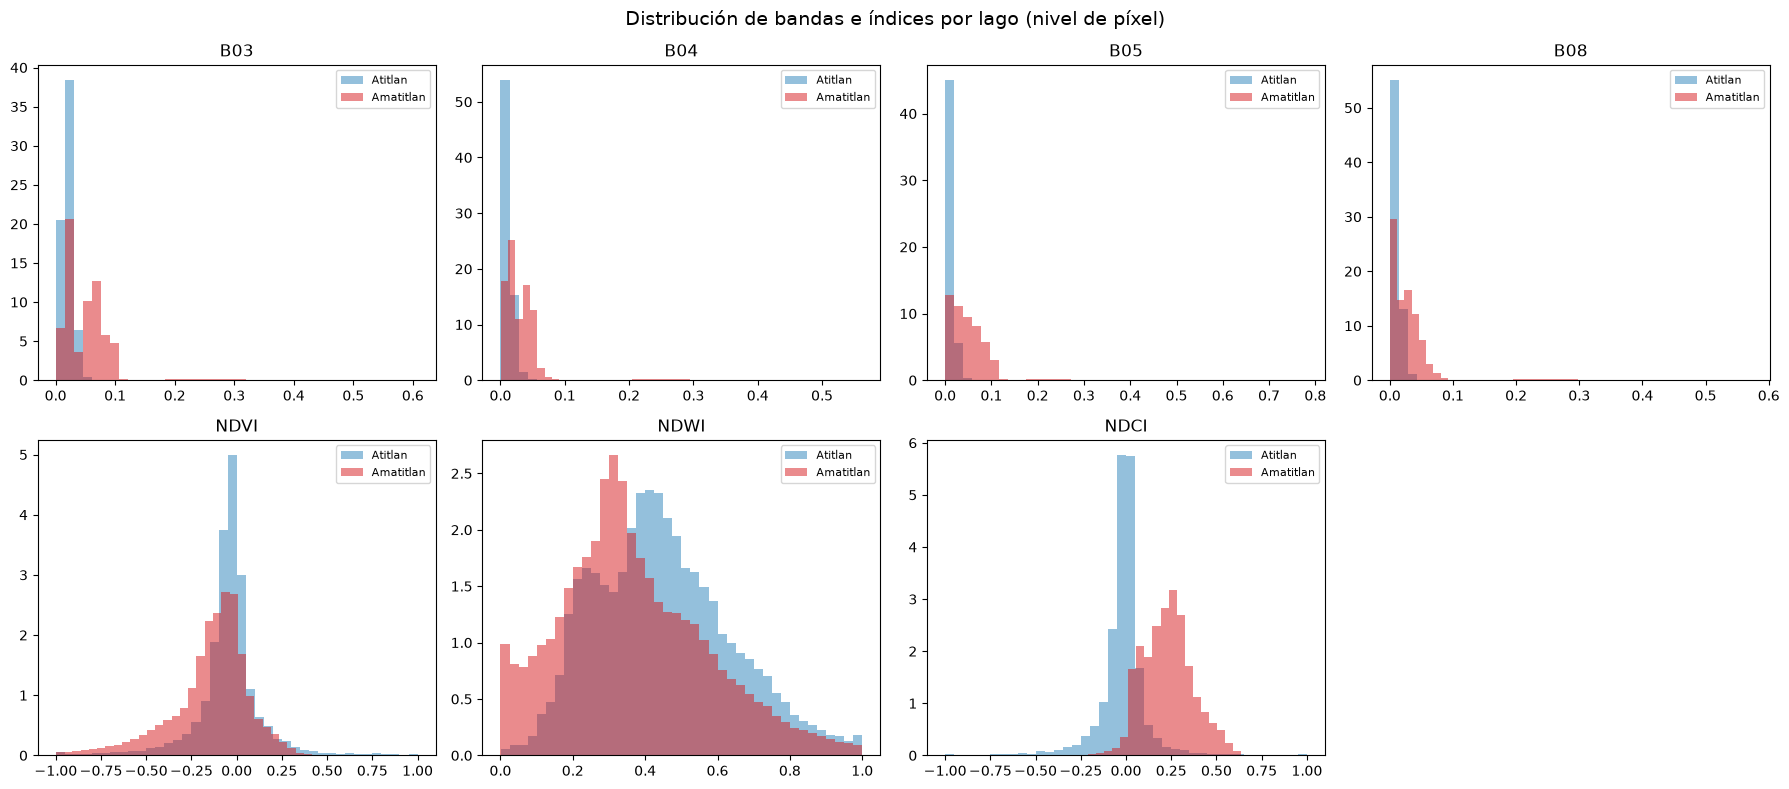

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, var in zip(axes, variables_num):
    for lago, color in zip(["atitlan", "amatitlan"], ["#2b83ba", "#d7191c"]):
        subset = df.loc[df["lago"] == lago, var]
        ax.hist(subset, bins=40, alpha=0.5, label=lago.capitalize(), color=color, density=True)
    ax.set_title(var)
    ax.legend(fontsize=8)
axes[-1].axis("off")
plt.suptitle("Distribución de bandas e índices por lago (nivel de píxel)", fontsize=14)
plt.tight_layout()
plt.show()


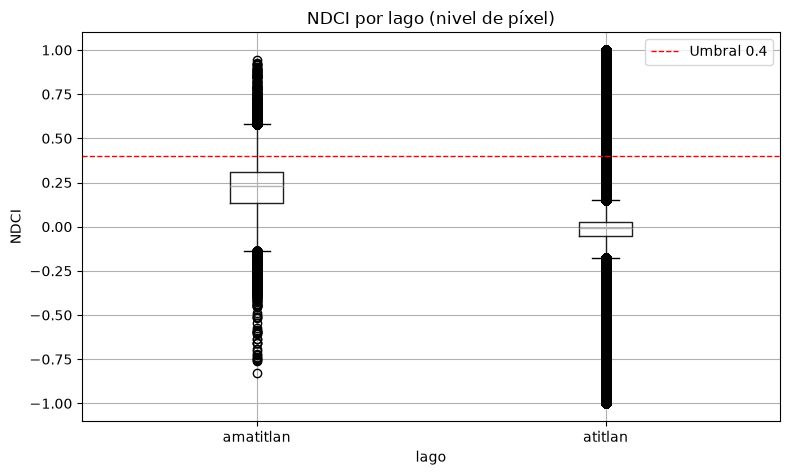

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column="NDCI", by="lago", ax=ax)
ax.set_title("NDCI por lago (nivel de píxel)")
ax.set_ylabel("NDCI")
plt.suptitle("")
plt.axhline(0.4, color="red", linestyle="--", linewidth=1, label="Umbral 0.4")
ax.legend()
plt.tight_layout()
plt.show()


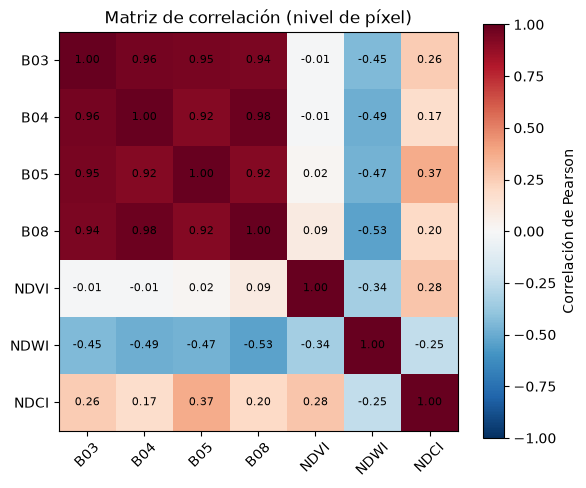

In [18]:
matriz_corr = df[variables_num].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matriz_corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(variables_num))); ax.set_xticklabels(variables_num, rotation=45)
ax.set_yticks(range(len(variables_num))); ax.set_yticklabels(variables_num)
for i in range(len(variables_num)):
    for j in range(len(variables_num)):
        ax.text(j, i, f"{matriz_corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Correlación de Pearson")
ax.set_title("Matriz de correlación (nivel de píxel)")
plt.tight_layout()
plt.show()


In [20]:
# Guardar el dataset limpio para los siguientes notebooks
Path("./data").mkdir(exist_ok=True)
df.to_parquet("./data/dataset_ml_pixeles.parquet", index=False)
df.to_csv("./data/dataset_ml_pixeles.csv", index=False)
print("Dataset guardado en ./data/dataset_ml_pixeles.parquet y .csv")


Dataset guardado en ./data/dataset_ml_pixeles.parquet y .csv


## 7. Resumen y justificación

| Decisión | Justificación |
|---|---|
| Una fila = un píxel-fecha, no un promedio por lago | El enunciado pide identificar "zonas" con alta cianobacteria, lo cual requiere resolución espacial o por píxel, no solo una serie temporal agregada. |
| Máscara de agua: NDWI (McFeeters) > 0 | Mismo criterio ya validado en `03_analisis_espacial_correlacion.ipynb` del lab anterior, ya que, el agua refleja más en verde que en NIR (NDWI positivo); tierra/vegetación al revés. Consistente con que el NDWI promedio del recuadro completo (mayormente tierra) resultó negativo en la Parte I. |
| Filtro de rango físico [-1,1] en NDVI/NDWI/NDCI | En aguas muy claras y profundas como Atitlán, el denominador de los índices puede acercarse a 0 y producir cocientes numéricamente inestables muy fuera de rango. Se descartan por ser artefactos del sensor/cálculo, no floraciones reales. |
| Filtro de reflectancia en [0,1] | Excluye errores de calibración/saturación del sensor. |
| Filtro proxy de nubes (B04 y B08 > 0.3) | No se descargó la banda SCL para minimizar volumen de descarga, así que se aproxima la detección de nubes con reflectancias anómalamente altas en rojo e infrarrojo cercano. |
| No se usa remuestreo espacial en este punto | Se conserva toda la resolución nativa; el submuestreo, si es necesario por balance de clases, se abordará en el notebook 02. |
